---



---

# **JOBSHEET 4 - SEGMENTASI GAMBAR**
***PENUGASAN NOMOR 3 DAN 4***

---



---

NAMA : Muhammad Eka Sobirin

NIM : 3.34.23.2.14

Mata Kuliah : Pengolahan Citra

Dosen Pengampu : Ir. Prayitno, S.ST., M.T., Ph.D.



---



---


##**PENUGASAN NOMOR 3**
### Eksperimen Thresholding

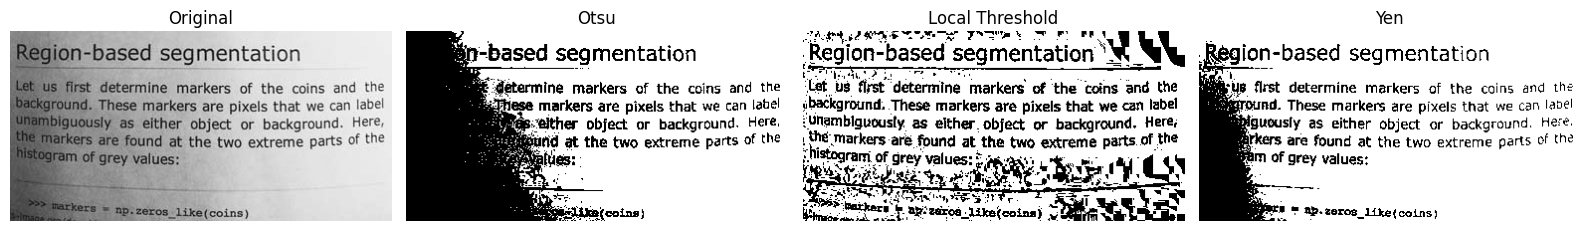

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra page
image = data.page()

# 2. Threshold Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. Threshold Local (Adaptive)
binary_local = image > filters.threshold_local(image, block_size=35)

# 4. Threshold Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title("Otsu")
axes[1].axis("off")

axes[2].imshow(binary_local, cmap='gray')
axes[2].set_title("Local Threshold")
axes[2].axis("off")

axes[3].imshow(binary_yen, cmap='gray')
axes[3].set_title("Yen")
axes[3].axis("off")

plt.tight_layout()
plt.show()

##**PENUGASAN NOMOR 4**
### Eksperimen Menggunakan Metode Segmentasi

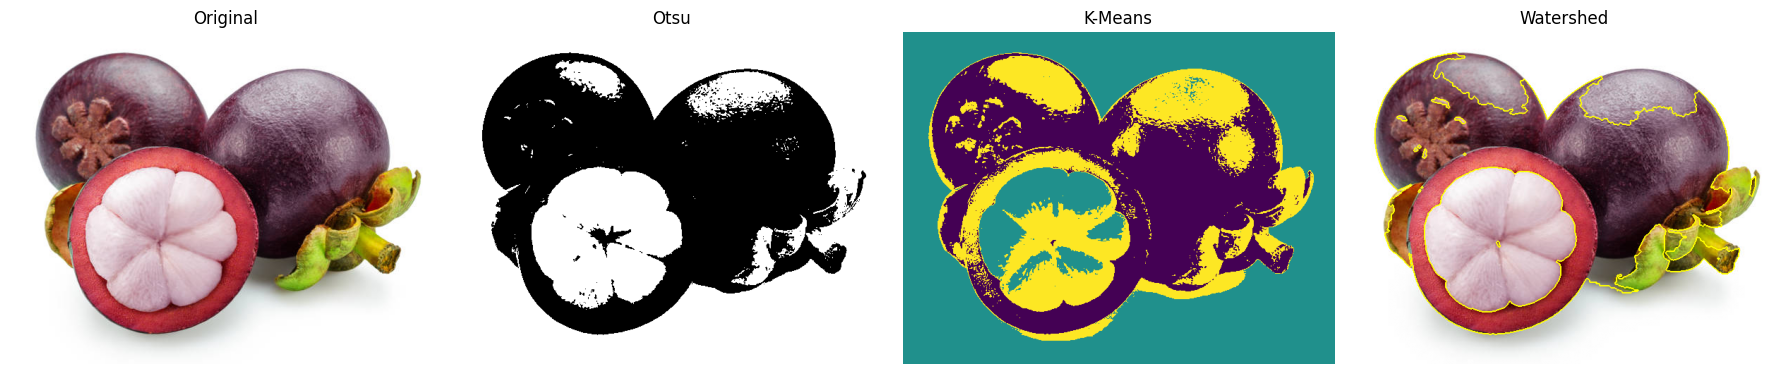

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color, filters, segmentation
from sklearn.cluster import KMeans
from skimage.color import rgb2lab
from skimage.filters import sobel

# 1. Load gambar
image = io.imread("sample_data/buah.jpg")
gray = color.rgb2gray(image)

# ===================================
# METODE 1 : OTSU
# ===================================
thresh = filters.threshold_otsu(gray)
otsu = gray > thresh

# ===================================
# METODE 2 : KMEANS
# ===================================
img_float = image / 255.0
rows, cols, ch = img_float.shape
pixels = img_float.reshape(rows*cols, ch)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixels)
kmeans_result = labels.reshape(rows, cols)

# ===================================
# METODE 3 : WATERSHED
# ===================================
gradient = sobel(gray)

markers = np.zeros_like(gray, dtype=np.int32)
markers[gray < 0.3] = 1
markers[gray > 0.7] = 2

ws = segmentation.watershed(gradient, markers)
ws_bound = segmentation.mark_boundaries(image, ws)

# ===================================
# VISUALISASI
# ===================================
fig, axes = plt.subplots(1,4, figsize=(18,5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(otsu, cmap='gray')
axes[1].set_title("Otsu")
axes[1].axis("off")

axes[2].imshow(kmeans_result, cmap='viridis')
axes[2].set_title("K-Means")
axes[2].axis("off")

axes[3].imshow(ws_bound)
axes[3].set_title("Watershed")
axes[3].axis("off")

plt.tight_layout()
plt.show()